In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv
import datetime
import os
import mplfinance as mpf
import re
import utils

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [3]:
start_time='08:30:00'
end_time='09:30:00'

In [4]:
query_min = "SELECT * FROM gold.active_1min WHERE bar_time BETWEEN %(start)s AND %(end)s ORDER BY bar_date, bar_time"
query_5min = "SELECT * FROM gold.active_5min WHERE bar_time BETWEEN %(start)s AND %(end)s ORDER BY bar_date, bar_time"
query_15min = "SELECT * FROM gold.active_15min WHERE bar_time BETWEEN %(start)s AND %(end)s ORDER BY bar_date, bar_time"

df_min = pd.read_sql(query_min,engine, params={"start": start_time, "end": end_time})
df_5min = pd.read_sql(query_5min,engine, params={"start": start_time, "end": end_time})
df_15min = pd.read_sql(query_15min,engine, params={"start": start_time, "end": end_time})

Filter Outliers

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.


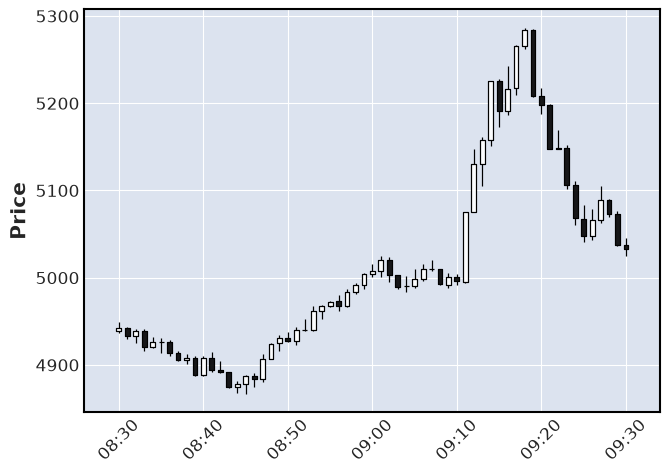

In [5]:
utils.visualize_barchart(df_min,datetime.date(2025,4,7))

In [17]:
df_min['price_movement'] = abs(df_min['high']-df_min['low'])
df_day = df_min.groupby('bar_date')['price_movement'].sum()
df_day
Q1, Q3 = df_day.quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outlier_dates = df_day[(df_day > upper_bound) | (df_day < lower_bound)].index

In [18]:
df_min = df_min[~df_min['bar_date'].isin(outlier_dates)]
df_5min = df_5min[~df_5min['bar_date'].isin(outlier_dates)]
df_15min = df_15min[~df_15min['bar_date'].isin(outlier_dates)]

Volume Analysis

In [20]:
volume_agg, volume_agg_IQR = utils.aggregate_by_time(df_min,'bar_time','volume')
xlabel_bins = 16

In [21]:
utils.get_basic_info(df_min,'volume')

count    13177.000000
mean      4443.337937
std       2475.368767
min          1.000000
25%       2751.000000
50%       3845.000000
75%       5473.000000
max      28029.000000
Name: volume, dtype: float64
Median:  3845.0
Std Dev:  2475.3687672470046
IQR: 2722.0


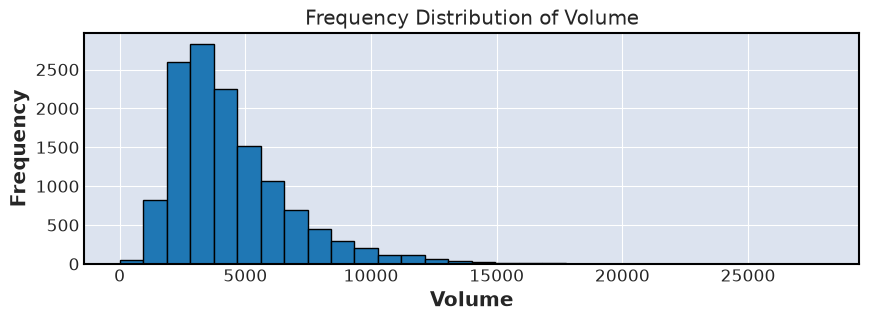

In [29]:
utils.frequency_hist(df_min,'volume',30,'Volume')

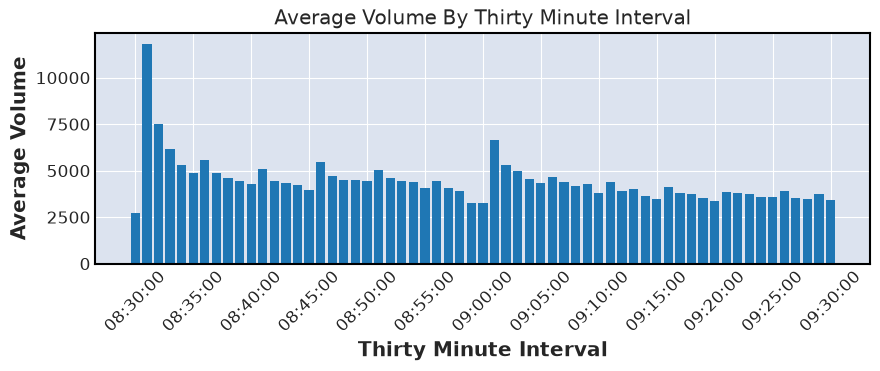

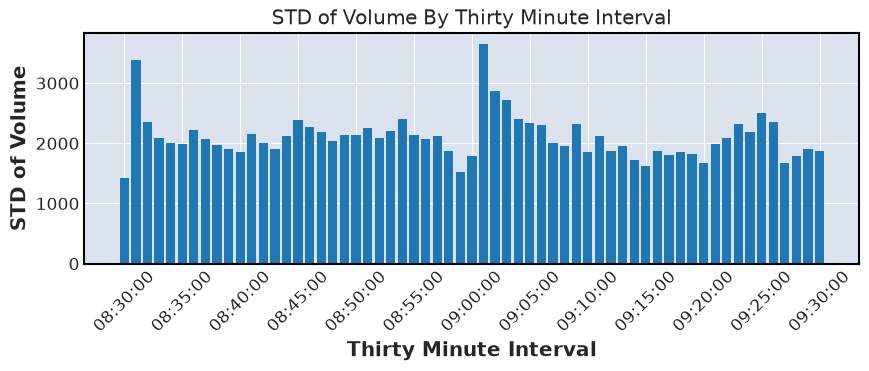

In [23]:
utils.bar_by_time(volume_agg,'mean','Thirty Minute Interval', 'Average Volume',tickbin=xlabel_bins)
utils.bar_by_time(volume_agg,'std','Thirty Minute Interval', 'STD of Volume',tickbin=xlabel_bins)

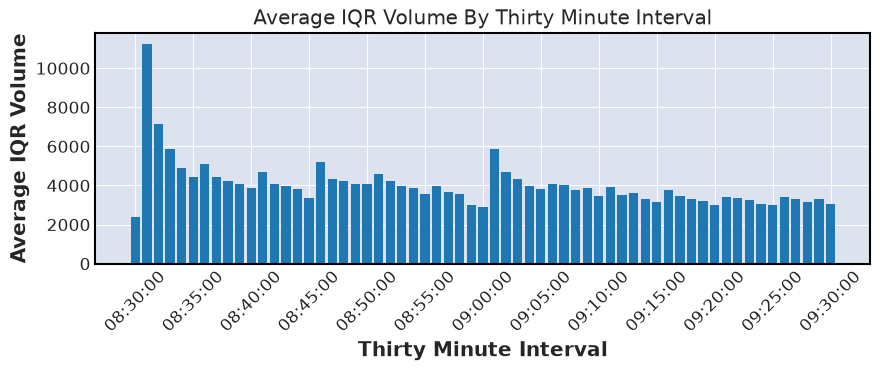

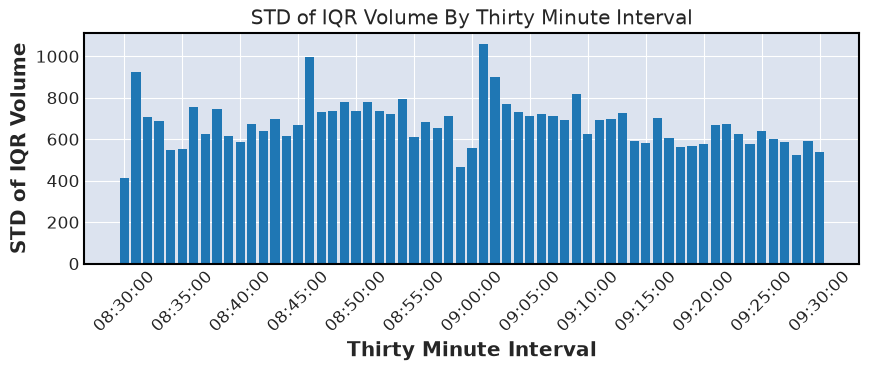

In [24]:
utils.bar_by_time(volume_agg_IQR,'mean','Thirty Minute Interval', 'Average IQR Volume',tickbin=xlabel_bins)
utils.bar_by_time(volume_agg_IQR,'std','Thirty Minute Interval', 'STD of IQR Volume',tickbin=xlabel_bins)

Swing Analysis

In [25]:
df_swings = utils.get_swings(df_min)

In [26]:
utils.get_basic_info(df_swings,'profit')

count    7182.000000
mean        3.370997
std         4.022280
min         0.000000
25%         0.750000
50%         2.000000
75%         4.500000
max        58.000000
Name: profit, dtype: float64
Median:  2.0
Std Dev:  4.02227952542954
IQR: 3.75


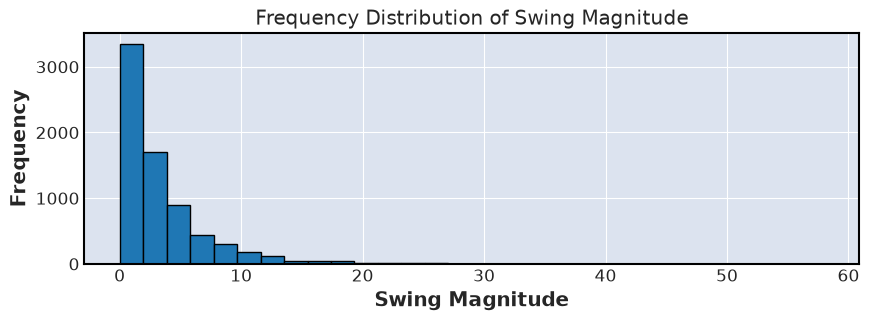

In [30]:
utils.frequency_hist(df_swings,'profit',30,'Swing Magnitude')

In [28]:
df_swings.sort_values('profit',ascending=False)

,date,time_start,time_end,duration,high,open,close,low,direction,profit,drawdown,bucket_30min,bucket_15min,bucket_5min
4792,2025-08-22,08:59:00,09:04:00,5,6472.00,6414.00,6469.50,6411.50,UP,58.00,2.50,08:30:00,08:45:00,08:55:00
892,2025-02-03,09:21:00,09:26:00,5,6008.50,5950.75,5999.75,5950.25,UP,57.75,0.50,09:00:00,09:15:00,09:20:00
2063,2025-04-15,09:16:00,09:21:00,5,5475.75,5470.00,5444.75,5433.00,DOWN,37.00,1.50,09:00:00,09:15:00,09:15:00
1023,2025-02-07,09:00:00,09:05:00,5,6120.50,6120.00,6089.25,6085.75,DOWN,34.25,1.50,09:00:00,09:00:00,09:00:00
1735,2025-03-14,08:59:00,09:01:00,2,5597.75,5596.00,5577.50,5564.00,DOWN,32.00,0.75,08:30:00,08:45:00,08:55:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3604,2025-07-07,09:09:00,09:10:00,1,6300.75,6300.25,6299.50,6298.25,NONE,0.00,0.00,09:00:00,09:00:00,09:05:00
3600,2025-07-07,09:03:00,09:04:00,1,6300.50,6300.50,6300.50,6295.50,UP,0.00,5.00,09:00:00,09:00:00,09:00:00
3625,2025-07-08,08:53:00,08:54:00,1,6282.75,6280.25,6281.50,6280.25,NONE,0.00,0.00,08:30:00,08:45:00,08:50:00
3560,2025-07-03,08:50:00,08:51:00,1,6309.00,6306.25,6307.50,6306.00,NONE,0.00,0.00,08:30:00,08:45:00,08:50:00
